# IR Spectroscopy of Everyday Materials

FT-IR absorption spectra for 23 household and laboratory samples collected on a Thermo Scientific Nicolet iS5 (ATR mode, 550–4,000 cm⁻¹). This notebook loads the cleaned data, plots individual spectra with functional group annotations, and identifies characteristic peaks.

## 1. Setup

Import libraries, define the sample index, and set up functional group annotation regions used across all plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import HTML, display
import os, warnings

# Suppress font fallback warnings (Colab lacks Times New Roman)
warnings.filterwarnings('ignore', message='.*findfont.*')

# Times New Roman with serif fallback for Colab
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Use local paths if available, otherwise fall back to GitHub raw URLs (for Colab)
LOCAL_SCRUBBED = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'SCRUBBED')
GITHUB_BASE = 'https://raw.githubusercontent.com/vivianweidai/research/main/20260401%20IR%20Spectroscopy/OUTPUT/SCRUBBED'

def load(name):
    local = os.path.join(LOCAL_SCRUBBED, f'{name}.csv')
    if os.path.exists(local):
        return pd.read_csv(local)
    return pd.read_csv(f'{GITHUB_BASE}/{name}.csv')

SAMPLES = {
    'Solvents':        ['acetone', 'isopropanol', 'water'],
    'Food/minerals':   ['coffee', 'salt', 'sugar'],
    'Personal care':   ['soap', 'shampoo', 'conditioner', 'lotion', 'sunscreen', 'cleaner'],
    'Polymers':        ['plastic_bag', 'plastic_cap', 'plastic_glove', 'plastic_wrapper', 'plastic_wrapper_2'],
    'Paper':           ['paper', 'paper_2', 'paper_plastic_cup'],
    'Biological':      ['finger', 'leaf', 'orange_peel'],
}

# Functional group regions for annotation
REGIONS = [
    (3200, 3600, 'O\u2013H stretch',   '#cce5ff'),
    (2850, 3000, 'C\u2013H stretch',   '#d4edda'),
    (1680, 1750, 'C=O stretch',         '#f8d7da'),
    (1600, 1680, 'C=C stretch',         '#fff3cd'),
    (1350, 1480, 'C\u2013H bend',      '#fce4b8'),
    (1000, 1300, 'C\u2013O stretch',   '#e2d9f3'),
]

def annotate_regions(ax):
    for lo, hi, label, color in REGIONS:
        ax.axvspan(lo, hi, alpha=0.35, color=color, zorder=0)
        ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.95, label,
                ha='center', va='top', fontsize=7, rotation=90, color='#555')

def format_ir_axes(ax):
    """Standard formatting for IR plots."""
    ax.set_xlim(4000, 550)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Absorbance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

display(HTML('<br>'))
HTML('<div style="background:#f6f8fa; border:1px solid #d0d7de; border-radius:6px; padding:12px;">'
     '<pre style="margin:0;">Setup complete \u2014 loaded sample index and helper functions.</pre></div>')

## 2. Acetone — Prototype Spectrum

Acetone is an ideal first sample — its spectrum has a sharp, unmistakable C=O carbonyl peak at ~1,715 cm⁻¹ and clean C–H stretches around 3,000 cm⁻¹. Shaded regions highlight the five main functional group zones.

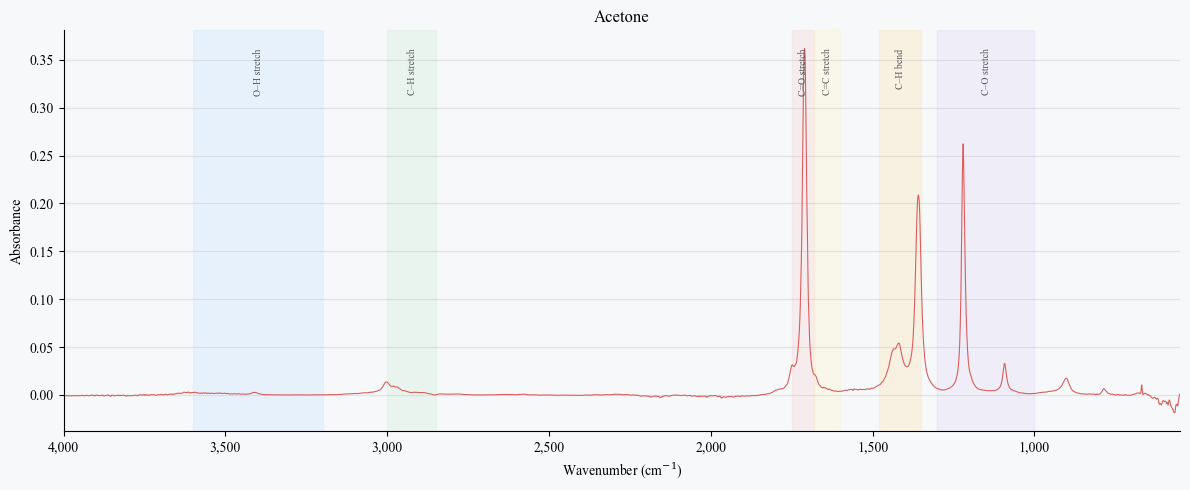

In [2]:
acetone = load('acetone')

fig, ax = plt.subplots(figsize=(12, 5))
fig.set_facecolor('#f6f8fa')
ax.set_facecolor('#f6f8fa')

ax.plot(acetone['wavenumber'], acetone['absorbance'], color='#d95f5f', linewidth=0.8)

# Annotate functional group regions
annotate_regions(ax)

format_ir_axes(ax)
ax.set_title('Acetone')

plt.tight_layout()
plt.savefig('acetone_spectrum.png', dpi=300, facecolor='#f6f8fa', bbox_inches='tight')
plt.savefig('acetone_spectrum.svg', facecolor='#f6f8fa', bbox_inches='tight')

display(HTML('<br>'))
plt.show()

## 3. Acetone — Peak Identification

Automatic peak detection using `scipy.signal.find_peaks` to locate the strongest absorptions, then match each peak to a known functional group assignment for acetone. Key features:

- **~1,715 cm⁻¹** — C=O carbonyl stretch, the dominant peak and most characteristic absorption in ketones
- **~2,950–3,000 cm⁻¹** — C–H stretching of the two methyl groups
- **~1,350–1,450 cm⁻¹** — C–H bending (symmetric and asymmetric scissoring of CH₃)
- **~1,000–1,300 cm⁻¹** — C–O and C–C skeletal stretches in the fingerprint region
- **No broad O–H band** around 3,200–3,600 cm⁻¹, confirming the sample is anhydrous

In [3]:
from scipy.signal import find_peaks

# Find prominent peaks in the acetone spectrum
peaks, props = find_peaks(acetone['absorbance'], height=0.02, prominence=0.01, distance=50)

peak_df = pd.DataFrame({
    'wavenumber': acetone['wavenumber'].iloc[peaks].values,
    'absorbance': acetone['absorbance'].iloc[peaks].values,
}).sort_values('absorbance', ascending=False).head(10)

# Known acetone assignments
ACETONE_ASSIGNMENTS = {
    (1700, 1730): 'C=O stretch (carbonyl)',
    (1350, 1380): 'C\u2013H bend (symmetric)',
    (1410, 1440): 'C\u2013H bend (asymmetric)',
    (1210, 1240): 'C\u2013C stretch',
    (2950, 3010): 'C\u2013H stretch (methyl)',
    (530, 570):   'C\u2013C=O bend',
}

def assign_peak(wn):
    for (lo, hi), label in ACETONE_ASSIGNMENTS.items():
        if lo <= wn <= hi:
            return label
    return ''

peak_df['assignment'] = peak_df['wavenumber'].apply(assign_peak)

display(HTML('<br>'))
HTML('<div style="background:#f6f8fa; border:1px solid #d0d7de; border-radius:6px; padding:12px; text-align:left;">'
     '<pre style="margin:0;">'
     + peak_df.to_string(index=False)
     + '</pre></div>')

---

<a href="https://colab.research.google.com/github/vivianweidai/research/blob/main/20260401%20IR%20Spectroscopy/OUTPUT/ir_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>&nbsp;&nbsp;Try running this analysis yourself in Google Colab — no setup required.